In [54]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
from pathlib import Path
import pandas as pd

from m5_forecasting.features.encoding import encode_categorical_features
from m5_forecasting.features.scaling import scale_features
from m5_forecasting.data.sequence import create_sequences
from m5_forecasting.data.split import train_val_test_split
from m5_forecasting.models.lstm import (
    build_lstm_model,
    get_callbacks
)

In [34]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed")

final_data = pd.read_parquet(
    DATA_PATH / "final_data.parquet"
)

In [35]:
final_data = final_data.dropna().reset_index(drop=True)

In [36]:
final_data, encoders = encode_categorical_features(final_data)

In [37]:
final_data, scaler = scale_features(final_data)

In [38]:
feature_columns = [
    "sell_price",
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
]

target_column = "sales"

In [39]:
X, y = create_sequences(
    final_data,
    feature_columns,
    target_column,
    sequence_length=28
)

In [40]:
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
) = train_val_test_split(X, y)

In [41]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(68, 28, 11)
(15, 28, 11)
(15, 28, 11)


In [42]:
print("Training sequences:", X_train.shape)
print("Validation sequences:", X_val.shape)
print("Test sequences:", X_test.shape)

if X_train.ndim != 3 or X_train.shape[1] == 0:
    raise ValueError("Expected 3D sequence data with at least one time step per sample.")

model = build_lstm_model(
    input_shape=(
        X_train.shape[1],
        X_train.shape[2]
    )
)

model.summary()

Training sequences: (68, 28, 11)
Validation sequences: (15, 28, 11)
Test sequences: (15, 28, 11)


/home/ibrahimkhan/m5-sales-forecasting/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import numpy as np

print("NaN in X:", np.isnan(X_train).sum())
print("NaN in y:", np.isnan(y_train).sum())

print("Inf in X:", np.isinf(X_train).sum())
print("Inf in y:", np.isinf(y_train).sum())

NaN in X: 0
NaN in y: 0
Inf in X: 0
Inf in y: 0


In [44]:
callbacks = get_callbacks()

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 343ms/step - loss: 8.3491 - mae: 1.4847 - val_loss: 1.7077 - val_mae: 0.9313
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 8.1491 - mae: 1.4395 - val_loss: 1.6070 - val_mae: 0.9200
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 7.9955 - mae: 1.4447 - val_loss: 1.5142 - val_mae: 0.9081
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 7.8168 - mae: 1.4474 - val_loss: 1.4073 - val_mae: 0.8938
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 7.6161 - mae: 1.4494 - val_loss: 1.2840 - val_mae: 0.8752
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 7.3650 - mae: 1.4526 - val_loss: 1.1439 - val_mae: 0.8505
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 7.0472 - mae: 1.4598 - val_loss: 0.9807 - val_mae: 0.8123
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 6.5887 - mae: 1.4602 - val_loss: 0.8592 - val_mae: 0.7474
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 6.1960 - mae: 1.4892 

In [46]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE : {test_mae:.4f}")

Test Loss: 1.1343
Test MAE : 0.9248


In [47]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions.flatten()
})

comparison.head(20)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


,Actual,Predicted
0,0,0.878315
1,1,0.963963
2,3,0.813858
3,0,0.720622
4,0,0.881446
5,0,0.874015
6,2,0.924935
7,0,0.834013
8,0,0.890801
9,0,0.935724


In [49]:
from pathlib import Path

MODEL_PATH = Path("../models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

In [50]:
model.save(MODEL_PATH / "lstm.keras")

In [51]:
import joblib

joblib.dump(scaler, MODEL_PATH / "scaler.pkl")

['../models/scaler.pkl']

In [52]:
joblib.dump(encoders, MODEL_PATH / "encoders.pkl")

['../models/encoders.pkl']

In [55]:
MODEL_PATH = Path("../models")

model = load_model(MODEL_PATH / "lstm.keras")

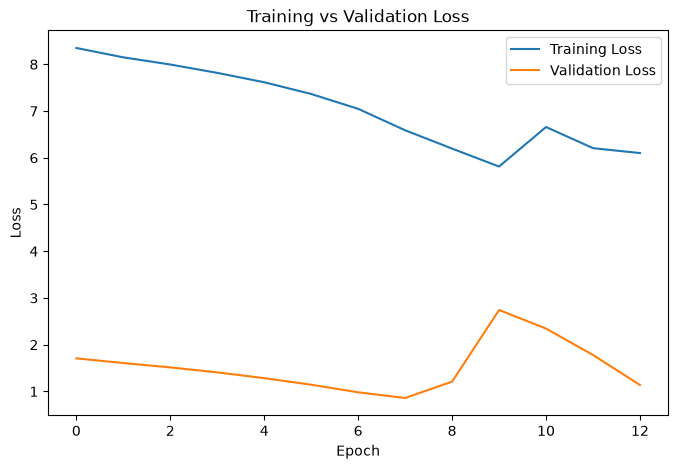

In [56]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

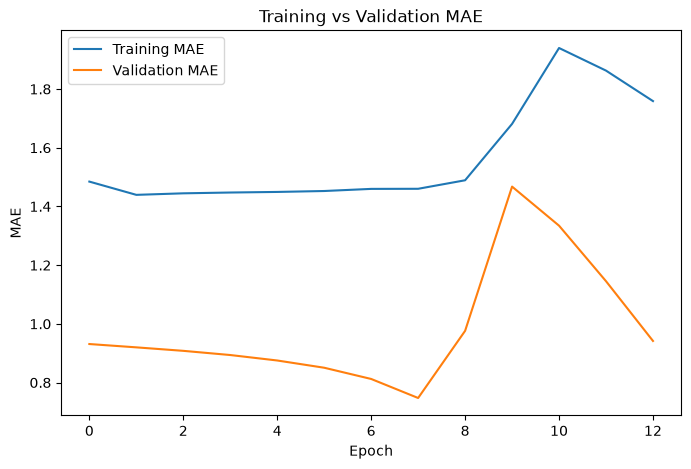

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

In [58]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

Test Loss : 1.1343
Test MAE  : 0.9248


In [59]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions.flatten()
})

comparison.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step


,Actual,Predicted
0,0,0.878315
1,1,0.963963
2,3,0.813858
3,0,0.720622
4,0,0.881446
5,0,0.874015
6,2,0.924935
7,0,0.834013
8,0,0.890801
9,0,0.935724


In [60]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.9248310923576355
RMSE: 1.065026700934302
R²  : 0.018409907817840576


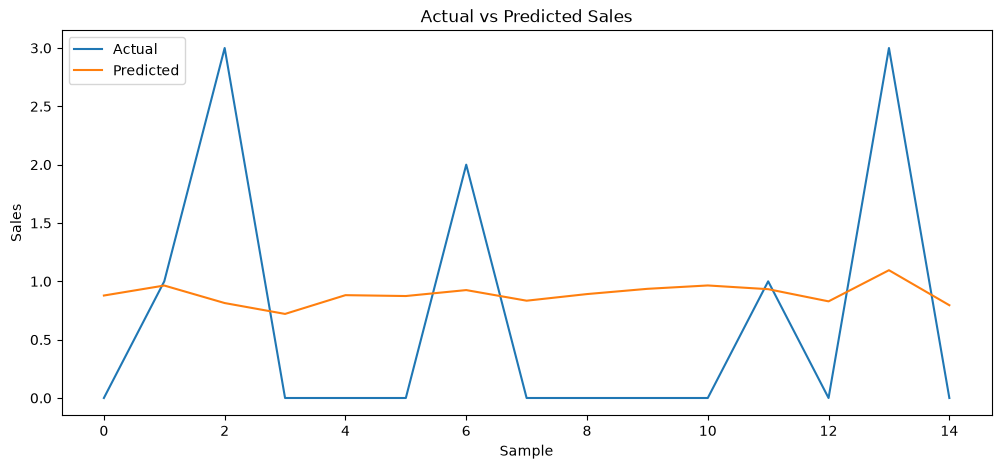

In [61]:
plt.figure(figsize=(12,5))

plt.plot(
    comparison["Actual"].values[:50],
    label="Actual"
)

plt.plot(
    comparison["Predicted"].values[:50],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Sample")

plt.ylabel("Sales")

plt.legend()

plt.show()

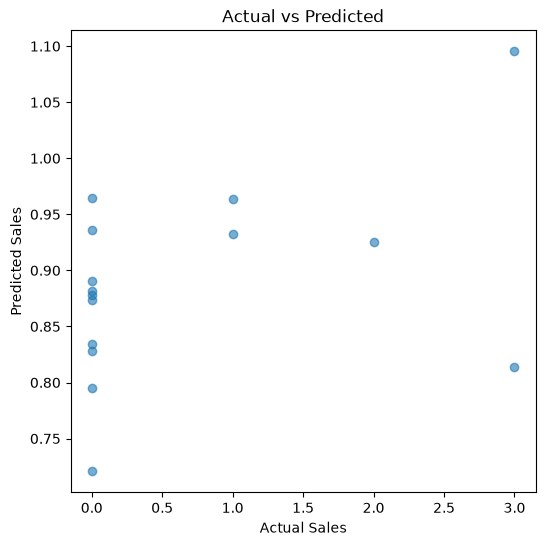

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
    alpha=0.6
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

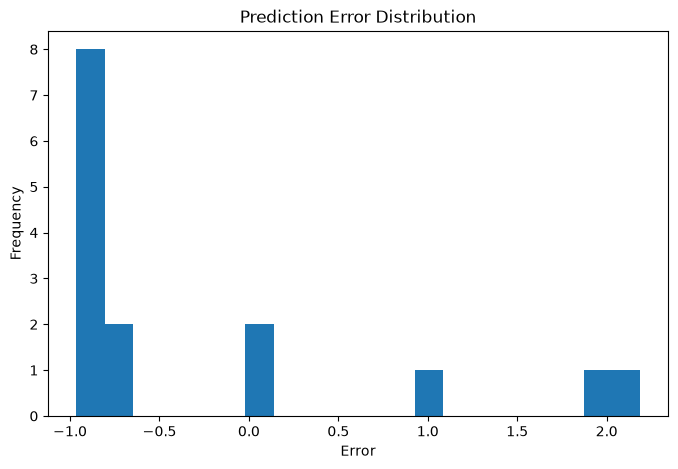

In [63]:
comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

plt.figure(figsize=(8,5))

plt.hist(
    comparison["Error"],
    bins=20
)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [65]:
REPORT_PATH = Path("../reports")

REPORT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

comparison.to_csv(
    REPORT_PATH / "predictions.csv",
    index=False
)

# Model Evaluation Summary

- Model: Single-layer LSTM
- Sequence Length: 28 days
- Training Sample: 100 products
- Test MAE: 0.9248
- The model successfully learned sales patterns on the sample dataset.
- Because the dataset was intentionally small, predictions tended toward the average sales value.
- Future improvements:
  - Increase the number of products.
  - Add more features (holiday indicators, SNAP, promotions).
  - Tune the LSTM architecture and hyperparameters.